Dataset obtained from 
https://www.kaggle.com/api/v1/datasets/download/taeefnajib/used-car-price-prediction-dataset

# Importing and cleaning NaN

In [1]:
import pandas as pd
df = pd.read_csv("used_cars.csv")
df.dropna()
idxs=[]
for row in df.itertuples():
    for i in row:
        if str(i) == "nan" or str(i) == "-":
            idxs.append(int(row.Index))
            #print(row)
            
print(idxs)

df.drop(idxs, inplace=True)
df.reset_index(inplace=True); df.drop("index", axis=1, inplace=True)
df
        

[2, 4, 5, 9, 10, 14, 20, 20, 22, 26, 32, 36, 41, 43, 44, 51, 56, 61, 63, 66, 68, 76, 80, 89, 89, 92, 96, 100, 102, 106, 112, 114, 120, 122, 123, 127, 128, 128, 129, 129, 129, 131, 131, 136, 139, 139, 143, 155, 156, 165, 168, 173, 176, 181, 189, 192, 193, 203, 205, 206, 208, 209, 216, 222, 224, 224, 225, 227, 230, 231, 232, 235, 235, 236, 236, 253, 254, 255, 256, 261, 262, 263, 266, 269, 270, 280, 291, 292, 294, 295, 298, 305, 313, 315, 321, 323, 326, 329, 330, 333, 334, 336, 340, 346, 349, 351, 354, 355, 356, 357, 357, 362, 364, 367, 369, 372, 376, 376, 383, 383, 390, 395, 396, 397, 406, 410, 413, 416, 422, 426, 426, 427, 431, 434, 436, 447, 448, 451, 456, 456, 463, 470, 472, 473, 476, 481, 482, 493, 496, 503, 504, 516, 518, 519, 519, 520, 526, 526, 526, 527, 529, 536, 541, 542, 543, 544, 546, 555, 555, 564, 576, 584, 591, 596, 599, 599, 606, 608, 614, 615, 616, 622, 623, 623, 627, 628, 630, 632, 633, 635, 636, 640, 640, 643, 646, 649, 649, 651, 653, 656, 676, 682, 683, 684, 687, 701, 

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
3,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
4,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
...,...,...,...,...,...,...,...,...,...,...,...,...
3264,Mercedes-Benz,E-Class E 300 4MATIC,2018,"53,705 mi.",Gasoline,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$25,900"
3265,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
3266,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
3267,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


# Setting column types

In [2]:
df.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

In [3]:
for col in df.columns:
    if df[col].dtype == int or df[col].dtype == float:
        continue
    else:
        list_val = list(set(df[col].values))
        if len(list_val) == 1: #deleting columns with only one element (not valuable for predictions)
            df.drop(col, axis = 1, inplace=True)
            
        if col == "price":
            df['price'] = (
                df['price']
                .astype(str)
                .str.replace('$', '', regex=False)
                .str.replace(',', '', regex=False)
            )
        if col == "milage":
            df['milage'] = (
                df['milage']
                .astype(str)
                .str.replace(' mi.', '', regex=False)
                .str.replace(',', '', regex=False)
            )  
        try:
            df[col] = df[col].astype(float) #numbers to float
            print(f"{col} changed to float")
        except:
            print(f"{col} remains object")
            

#print(df.dtypes)
df 


brand remains object
model remains object
milage changed to float
fuel_type remains object
engine remains object
transmission remains object
ext_col remains object
int_col remains object
accident remains object
clean_title remains object
price changed to float


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,38005.0
2,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,15500.0
3,Audi,S3 2.0T Premium Plus,2017,84000.0,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,31000.0
4,BMW,740 iL,2001,242000.0,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,7300.0
...,...,...,...,...,...,...,...,...,...,...,...
3264,Mercedes-Benz,E-Class E 300 4MATIC,2018,53705.0,Gasoline,241.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,25900.0
3265,Bentley,Continental GT Speed,2023,714.0,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,349950.0
3266,Audi,S4 3.0T Premium Plus,2022,10900.0,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,53900.0
3267,Ford,F-150 Raptor,2020,33000.0,Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,62999.0


# Dealing with outliers

In [4]:
df['milage'] = df['milage'].clip(
    df['milage'].quantile(0.01),
    df['milage'].quantile(0.99)
)

In [5]:
import numpy as np
df['price'] = np.log1p(df['price'])

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(outliers.shape)
outliers.head(5)

(45, 11)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
10,Mercedes-Benz,Metris Base,2021,1685.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,9-Speed Automatic,Gray,White,None reported,12.429220
69,Aston,Martin DBS Superleggera,2021,2165.0,Gasoline,5.2L V12 48V GDI DOHC Twin Turbo,8-Speed Automatic,Black,Black,None reported,12.542370
134,Porsche,911 GT2 RS,2018,4529.0,Gasoline,3.8L H6 24V GDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,Black,Black,None reported,12.942042
169,Bugatti,Veyron 16.4 Grand Sport,2011,6330.0,Gasoline,8.0L W16 64V GDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,White,White,None reported,14.483851
189,Lamborghini,Urus Base,2021,13692.0,Gasoline,641.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,8-Speed A/T,Black,Red,None reported,12.456835


# Symplifying dataset (engine -> HP, Cylinder, Size (L) /// Transmission -> Auto/Manual/CVT /// Fuel -> Gas/Hyb/Diesel)

This allows the model to generalize better

In [6]:
#special mention: for differenciatinf int and ext colors:
def simplify_color_ext(x):
    return f"ext_{x}"
df['ext_col'] = df['ext_col'].apply(simplify_color_ext)

def simplify_color_int(x):
    return f"int_{x}"
df['int_col'] = df['int_col'].apply(simplify_color_int)

In [7]:
import re
modified=[]
#fuel
def simplify_fuel(x):
    if x == 'Gasoline':
        return 'Gasoline'
    elif 'Hybrid' in str(x):
        return 'Hybrid'
    elif x == 'Diesel':
        return 'Diesel'
    else:
        return 'Other_fuel'

df['fuel_type'] = df['fuel_type'].apply(simplify_fuel)


#engine
df['HP'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df['Engine_Size'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
df['Cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)
## filling gaps
df['HP'].fillna(df['HP'].median(), inplace=True)
df['Engine_Size'].fillna(df['Engine_Size'].median(), inplace=True)
df['Cylinders'].fillna(df['Cylinders'].median(), inplace=True)

df.drop("engine", axis = 1, inplace = True)
modified.append("HP")
modified.append("Engine_Size")
modified.append("Cylinders")

#transmission
def simplify_trans(x):
    x = str(x)

    if 'A/T' in x or 'Automatic' in x:
        return 'Automatic'
    
    elif 'M/T' in x or 'Manual' in x:
        return 'Manual'
    
    elif 'CVT' in x:
        return 'CVT'
    
    else:
        return 'Other_transmission'

df['transmission'] = df['transmission'].apply(simplify_trans)


df

/tmp/ipykernel_4209/979739333.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HP'].fillna(df['HP'].median(), inplace=True)
/tmp/ipykernel_4209/979739333.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,price,HP,Engine_Size,Cylinders
0,Ford,Utility Police Interceptor Base,2013,51000.00,Other_fuel,Automatic,ext_Black,int_Black,At least 1 accident or damage reported,9.239996,300.0,3.7,6.0
1,Hyundai,Palisade SEL,2021,34742.00,Gasoline,Automatic,ext_Moonlight Cloud,int_Gray,At least 1 accident or damage reported,10.545499,310.0,3.8,6.0
2,INFINITI,Q50 Hybrid Sport,2015,88900.00,Hybrid,Automatic,ext_Black,int_Black,None reported,9.648660,354.0,3.5,6.0
3,Audi,S3 2.0T Premium Plus,2017,84000.00,Gasoline,Automatic,ext_Blue,int_Black,None reported,10.341775,292.0,2.0,4.0
4,BMW,740 iL,2001,229144.00,Gasoline,Automatic,ext_Green,int_Green,None reported,8.895767,282.0,4.4,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,Mercedes-Benz,E-Class E 300 4MATIC,2018,53705.00,Gasoline,Automatic,ext_Black,int_Black,At least 1 accident or damage reported,10.162037,241.0,2.0,4.0
3265,Bentley,Continental GT Speed,2023,996.48,Gasoline,Automatic,ext_C / C,int_Hotspur,None reported,12.765548,310.0,6.0,6.0
3266,Audi,S4 3.0T Premium Plus,2022,10900.00,Gasoline,Other_transmission,ext_Black,int_Black,None reported,10.894904,349.0,3.0,6.0
3267,Ford,F-150 Raptor,2020,33000.00,Gasoline,Automatic,ext_Blue,int_Black,None reported,11.050890,450.0,3.5,6.0


# Dealing with small amount of data

Columns with unique elements may be consider as outliers too

In [8]:
from collections import Counter

df = df.copy()
discarded = {}

for col in df.select_dtypes(include="object").columns:
    counts = df[col].value_counts()
    
    rare_values = counts[counts < 20].index
    discarded[col] = list(rare_values)
    
    df[col] = df[col].where(~df[col].isin(rare_values), f"other_{col}")
    
    
df

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,price,HP,Engine_Size,Cylinders
0,Ford,other_model,2013,51000.00,Other_fuel,Automatic,ext_Black,int_Black,At least 1 accident or damage reported,9.239996,300.0,3.7,6.0
1,Hyundai,other_model,2021,34742.00,Gasoline,Automatic,other_ext_col,int_Gray,At least 1 accident or damage reported,10.545499,310.0,3.8,6.0
2,INFINITI,other_model,2015,88900.00,Hybrid,Automatic,ext_Black,int_Black,None reported,9.648660,354.0,3.5,6.0
3,Audi,other_model,2017,84000.00,Gasoline,Automatic,ext_Blue,int_Black,None reported,10.341775,292.0,2.0,4.0
4,BMW,other_model,2001,229144.00,Gasoline,Automatic,ext_Green,other_int_col,None reported,8.895767,282.0,4.4,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,Mercedes-Benz,other_model,2018,53705.00,Gasoline,Automatic,ext_Black,int_Black,At least 1 accident or damage reported,10.162037,241.0,2.0,4.0
3265,Bentley,other_model,2023,996.48,Gasoline,Automatic,other_ext_col,other_int_col,None reported,12.765548,310.0,6.0,6.0
3266,Audi,other_model,2022,10900.00,Gasoline,Other_transmission,ext_Black,int_Black,None reported,10.894904,349.0,3.0,6.0
3267,Ford,other_model,2020,33000.00,Gasoline,Automatic,ext_Blue,int_Black,None reported,11.050890,450.0,3.5,6.0


saving pre-normallized and pre-dummied df for illustrations

In [9]:
import pandas as pd
import numpy as np
import copy
saved_df = copy.deepcopy(df)
def real_price(x):
    return round(np.expm1(x),2)
def original_col(x):
    if str(x).startswith("other"):
        return "other"
    else:
        return x[4:]
saved_df['price'] = saved_df['price'].apply(real_price)
saved_df["ext_col"] = saved_df["ext_col"].apply(original_col)
saved_df["int_col"] = saved_df["int_col"].apply(original_col)
saved_df.to_parquet("pre_norm_dummied_df.parquet",engine="pyarrow")

In [10]:
dummies = []
for col in df.columns:
    if df[col].dtype == object:
        list_val = list(set(df[col].values))
        val = df[col].value_counts()
        ky = val.keys()
        v = list(val)
        if str(ky[0]).startswith("other") and v[0]/sum(v) > 0.8: # if column has too many "other", is not a representative one
            print(f"{col} depreciated")
            df.drop(col, axis = 1, inplace = True)
        elif len(list_val) <= 15:
            print(f"{col} modified dummy") #dummies for better object interpretation
            dum_df = pd.get_dummies(list(df[col].values), dtype=float)
            df = pd.concat([df,dum_df], axis = 1)
            df.drop(col, axis = 1, inplace = True)
            modified.extend(dum_df.columns)
            dummies.extend(dum_df.columns)
df

model depreciated
fuel_type modified dummy
transmission modified dummy
ext_col modified dummy
int_col modified dummy
accident modified dummy


,brand,model_year,milage,price,HP,Engine_Size,Cylinders,Diesel,Gasoline,Hybrid,...,int_Blue,int_Brown,int_Gray,int_Jet Black,int_Red,int_White,int_–,other_int_col,At least 1 accident or damage reported,None reported
0,Ford,2013,51000.00,9.239996,300.0,3.7,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Hyundai,2021,34742.00,10.545499,310.0,3.8,6.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,INFINITI,2015,88900.00,9.648660,354.0,3.5,6.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Audi,2017,84000.00,10.341775,292.0,2.0,4.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,BMW,2001,229144.00,8.895767,282.0,4.4,8.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,Mercedes-Benz,2018,53705.00,10.162037,241.0,2.0,4.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3265,Bentley,2023,996.48,12.765548,310.0,6.0,6.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3266,Audi,2022,10900.00,10.894904,349.0,3.0,6.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3267,Ford,2020,33000.00,11.050890,450.0,3.5,6.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Splitting to avoid data leakage

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.25, random_state=33)

# Dealing with categorical_large columns 

The ones that were not converted into dummies because of their size (use TargetEncoder)

In [12]:
import joblib
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import TargetEncoder
for col in X_train.columns:
    if X_train[col].dtype == object and not col in modified:
        list_val = list(set(X_train[col].values))
        print(f"Unique values for {col} = {len(list_val)}")             
        encoder = TargetEncoder(cols=[col], smoothing=50, min_samples_leaf=20)
        X_train[f'encoded_{col}'] = encoder.fit_transform(X_train[col], Y_train)
        X_test[f'encoded_{col}'] = encoder.transform(X_test[col])
        # save eoncder for each column (joblib)
        X_train.drop(col, axis = 1, inplace = True)
        X_test.drop(col, axis = 1, inplace = True)
        
        
joblib.dump(encoder, 'Target_encoder.pkl')

X_train

Unique values for brand = 33


,model_year,milage,HP,Engine_Size,Cylinders,Diesel,Gasoline,Hybrid,Other_fuel,Automatic,...,int_Brown,int_Gray,int_Jet Black,int_Red,int_White,int_–,other_int_col,At least 1 accident or damage reported,None reported,encoded_brand
974,2021,3000.0,460.0,5.0,8.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.198396
2530,2020,33060.0,285.0,3.6,6.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.054677
955,2017,44000.0,152.0,2.0,4.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.057420
21,2018,28800.0,362.0,3.0,6.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.516451
1444,2002,103500.0,190.0,4.0,6.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.054677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2706,2021,17836.0,310.0,2.0,6.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,10.198396
578,2023,20121.0,311.0,3.5,6.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,10.173352
1752,2022,18465.0,400.0,3.5,6.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.198396
2439,2000,74000.0,200.0,3.8,6.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,10.204139


# Normalize (except dummies and target)

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib

# Columnas a normalizar (todo menos las binarias)
cols_to_scale = list(set(X_train.columns) - set(dummies))

# Columnas que NO se tocan (ya son 0/1)
binary_cols = modified

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test_scaled

joblib.dump(scaler, 'StandardScaler.pkl')


['StandardScaler.pkl']

# Model

ElasticNet (combines Ridge + Lasso)

In [14]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
import statistics
k = 5 
kf = KFold(n_splits=k, shuffle=True, random_state=33)

sc_model=[]; best_a = 0; best_l1 = 0; best_model = None; max_sc = 0
for a in [0.05, 0.07, 0.1, 0.5, 1.0, 2.0]:
    for l1 in [0.1, 0.2, 0.4, 0.7, 0.9]:
        sc_epoch = []; max_epoch = 0; best_model_epoch = None
        for epoch in range(40):
            modelo = ElasticNet(alpha=a, l1_ratio=l1) 
            results = cross_validate(modelo, X_train_scaled, Y_train, cv=kf, return_estimator=True)
            
            scores = results["test_score"]
            sc_epoch.append(statistics.mean(scores))
            
            if statistics.mean(scores) > max_epoch:
                max_epoch = statistics.mean(scores)
                best_model_index = int(results["test_score"].argmax())
                best_model_epoch = results["estimator"][best_model_index]
                
        print(f"Model: alpha = {a}, l1 = {l1} -> Score = {statistics.mean(sc_epoch)}")
        if max_epoch > max_sc:
            max_sc = max_epoch
            best_a = a
            best_l1 = l1
            best_model = best_model_epoch
        sc_model.append(statistics.mean(sc_epoch))
        
#save
    

Model: alpha = 0.05, l1 = 0.1 -> Score = 0.7767630758427241
Model: alpha = 0.05, l1 = 0.2 -> Score = 0.7714102525920434
Model: alpha = 0.05, l1 = 0.4 -> Score = 0.76768496518193
Model: alpha = 0.05, l1 = 0.7 -> Score = 0.7644226813786068
Model: alpha = 0.05, l1 = 0.9 -> Score = 0.7614569845495988
Model: alpha = 0.07, l1 = 0.1 -> Score = 0.7734008288608919
Model: alpha = 0.07, l1 = 0.2 -> Score = 0.7690416093400726
Model: alpha = 0.07, l1 = 0.4 -> Score = 0.7651940536093309
Model: alpha = 0.07, l1 = 0.7 -> Score = 0.7589021418674243
Model: alpha = 0.07, l1 = 0.9 -> Score = 0.753033520401098
Model: alpha = 0.1, l1 = 0.1 -> Score = 0.7695878006657192
Model: alpha = 0.1, l1 = 0.2 -> Score = 0.7655866130379485
Model: alpha = 0.1, l1 = 0.4 -> Score = 0.760088659301419
Model: alpha = 0.1, l1 = 0.7 -> Score = 0.7473537712033285
Model: alpha = 0.1, l1 = 0.9 -> Score = 0.7361155718247356
Model: alpha = 0.5, l1 = 0.1 -> Score = 0.7138516407579226
Model: alpha = 0.5, l1 = 0.2 -> Score = 0.67943692

In [15]:
import joblib
joblib.dump(best_model, 'elastic_net_model.pkl')
best_model

ElasticNet(alpha=0.05, l1_ratio=0.1)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test_scaled)

# y_test: actual values, y_pred: predicted values
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.2842635664664664
MSE: 0.20276482629907364
RMSE: 0.4502941553019244
R2 Score: 0.7407140209833136


# Making predictions

In [17]:
X_train.columns

Index(['model_year', 'milage', 'HP', 'Engine_Size', 'Cylinders', 'Diesel',
       'Gasoline', 'Hybrid', 'Other_fuel', 'Automatic', 'CVT', 'Manual',
       'Other_transmission', 'ext_Beige', 'ext_Black', 'ext_Blue', 'ext_Brown',
       'ext_Gold', 'ext_Gray', 'ext_Green', 'ext_Orange', 'ext_Red',
       'ext_Silver', 'ext_White', 'ext_Yellow', 'other_ext_col', 'int_Beige',
       'int_Black', 'int_Blue', 'int_Brown', 'int_Gray', 'int_Jet Black',
       'int_Red', 'int_White', 'int_–', 'other_int_col',
       'At least 1 accident or damage reported', 'None reported',
       'encoded_brand'],
      dtype='object')

In [18]:
#norm using scaler
mod_year = 2019
brand = "Ford" # target enconder
milage = 18000
hp = 140
eng_size = 1.8
Cylinders = 4
fuel = "Gasoline" # dummies 'Diesel','Gasoline', 'Hybrid', 'Other_fuel'
gearbox = "Manual" #dummies 'Automatic', 'CVT', 'Manual','Other_transmission'
ext_color = "Red" #dummies  'ext_Beige', 'ext_Black', 'ext_Blue', 'ext_Brown','ext_Gold', 'ext_Gray', 'ext_Green', 'ext_Orange', 'ext_Red','ext_Silver', 'ext_White', 'ext_Yellow', 'other_ext_col'
int_color = "Blue" #dummies 'int_Beige','int_Black', 'int_Blue', 'int_Brown', 'int_Gray', 'int_Jet Black','int_Red', 'int_White', 'int_–', 'other_int_col'
accident = "None reported" #dummies 'At least 1 accident or damage reported', 'None reported'

In [19]:
new_list = [float(mod_year), float(milage), float(hp), float(eng_size), float(Cylinders)]
elements_list = [['Diesel','Gasoline', 'Hybrid', 'Other_fuel'],['Automatic', 'CVT', 'Manual','Other_transmission'],['Beige', 'Black', 'Blue', 'Brown','Gold', 'Gray', 'Green', 'Orange', 'Red','Silver', 'White', 'Yellow', 'other'],['Beige','Black', 'Blue', 'Brown', 'Gray', 'Jet Black','Red', 'White', '–', 'other'],['At least 1 accident or damage reported', 'None reported']]
target_dumm_list = [fuel, gearbox, ext_color, int_color, accident]
for ele, tat in zip(elements_list, target_dumm_list):
    ele_idx = ele.index(tat)
    dumm_ele = [0.0]*len(ele); dumm_ele[ele_idx] = 1.0
    new_list.extend(dumm_ele)
enco_brand_df=pd.DataFrame([brand],columns = ["brand"])
enco_brand = encoder.transform(enco_brand_df["brand"])
enco_brand.values[0][0]
new_list.append(enco_brand.values[0][0])


In [20]:
assert(len(X_test.columns) == len(new_list))
new_list_scaled = pd.DataFrame(new_list).transpose()
new_list_scaled.columns = X_test.columns
new_list_scaled[cols_to_scale] = scaler.transform(new_list_scaled[cols_to_scale])
new_list_scaled


,model_year,milage,HP,Engine_Size,Cylinders,Diesel,Gasoline,Hybrid,Other_fuel,Automatic,...,int_Brown,int_Gray,int_Jet Black,int_Red,int_White,int_–,other_int_col,At least 1 accident or damage reported,None reported,encoded_brand
0,0.714204,-1.039769,-1.738201,-1.38259,-1.429775,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.111681


In [21]:
y_pred = best_model.predict(new_list_scaled)
print(round(np.expm1(y_pred)[0],2))

28127.26


# Creating graphs

In [22]:
set(df["brand"])

{'Acura',
 'Audi',
 'BMW',
 'Bentley',
 'Buick',
 'Cadillac',
 'Chevrolet',
 'Chrysler',
 'Dodge',
 'Ford',
 'GMC',
 'Honda',
 'Hyundai',
 'INFINITI',
 'Jaguar',
 'Jeep',
 'Kia',
 'Land',
 'Lexus',
 'Lincoln',
 'MINI',
 'Maserati',
 'Mazda',
 'Mercedes-Benz',
 'Mitsubishi',
 'Nissan',
 'Porsche',
 'RAM',
 'Subaru',
 'Toyota',
 'Volkswagen',
 'Volvo',
 'other_brand'}

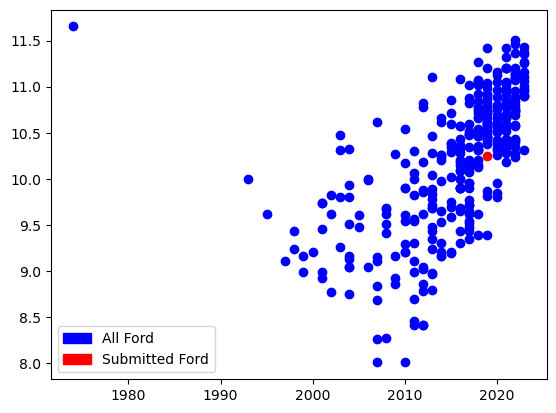

In [23]:
import matplotlib.pyplot as plt

new_list_plot = pd.DataFrame(new_list).transpose()
new_list_plot.columns = X_test.columns
import matplotlib.patches as mpatches

# colors = {
#     'Acura': '#E6194B',
#     'Audi': '#3CB44B',
#     'BMW': '#4363D8',
#     'Bentley': '#911EB4',
#     'Buick': '#F58231',
#     'Cadillac': '#42D4F4',
#     'Chevrolet': '#F032E6',
#     'Chrysler': '#469990',
#     'Dodge': '#FABED4',
#     'Ford': '#008080',
#     'GMC': '#E6BEFF',
#     'Honda': '#9A6324',
#     'Hyundai': '#800000',
#     'INFINITI': '#AAFFC3',
#     'Jaguar': '#808000',
#     'Jeep': '#000075',
#     'Kia': '#A9A9A9',
#     'Land': '#FF6347',
#     'Lexus': '#7FFFD4',
#     'Lincoln': '#DC143C',
#     'MINI': '#00CED1',
#     'Maserati': '#FF8C00',
#     'Mazda': '#8A2BE2',
#     'Mercedes-Benz': '#20B2AA',
#     'Mitsubishi': '#FF1493',
#     'Nissan': '#1E90FF',
#     'Porsche': '#32CD32',
#     'RAM': '#FFD700',
#     'Subaru': '#6A5ACD',
#     'Toyota': '#FF4500',
#     'Volkswagen': '#00BFFF',
#     'Volvo': '#8B4513',
#     'other_brand': '#696969'
# }
# #select corrrct color
# for k,v in colors.items():
#     if k != brand:
#         colors[k] = "Black"

# # 2. Map column to colors
# color_list = [colors[c] for c in df['brand']]

plt.scatter(df[df["brand"] == brand]["model_year"], df[df["brand"] == brand]["price"], c= "blue")
plt.scatter(new_list_plot["model_year"], y_pred, color= "red")


legend_handles = [
    mpatches.Patch(color="blue", label=f'All {brand}'),
    mpatches.Patch(color="red", label=f'Submitted {brand}')
]
plt.legend(handles=legend_handles)
plt.show()

# Obtaining model coefficients

In [24]:
coefs=best_model.coef_
coefs

array([ 0.25409387, -0.33413897,  0.21984117,  0.10457934, -0.01173673,
        0.0560376 , -0.07724676,  0.        , -0.        , -0.01670506,
       -0.        ,  0.02327716,  0.        , -0.        ,  0.        ,
       -0.        , -0.        , -0.        , -0.        ,  0.        ,
        0.        ,  0.        , -0.00271933,  0.        ,  0.        ,
        0.03768364, -0.01780687, -0.        ,  0.        ,  0.        ,
       -0.00378847,  0.        ,  0.        ,  0.        ,  0.        ,
        0.03567452, -0.0345665 ,  0.03450724,  0.16993395])

In [25]:
import pickle as pkl
elements_list_coef = [["model_year"],["milage"],["HP"],["Engine_Size"],["Cylinders"],['Diesel','Gasoline', 'Hybrid', 'Other_fuel'],['Automatic', 'CVT', 'Manual','Other_transmission'],['Beige', 'Black', 'Blue', 'Brown','Gold', 'Gray', 'Green', 'Orange', 'Red','Silver', 'White', 'Yellow', 'other'],['Beige','Black', 'Blue', 'Brown', 'Gray', 'Jet Black','Red', 'White', '–', 'other'],['At least 1 accident or damage reported', 'None reported'],["brand"]]
column_names = ["Year", "Milage", "HorsePower", "Engine (L)", "Cylinders", "Fuel", "Gearbox", "Exterior color", "Interior color", "Accidents","Car brand"]

i_name = 0
i_element = 0
coef_dict={}
name_coef = 0
for ele in elements_list_coef:
    for sub_ele in ele:
        name_coef = name_coef + abs(coefs[i_element])
        i_element = i_element + 1
    coef_dict[column_names[i_name]] =name_coef 
    name_coef = 0
    i_name = i_name +1
    
coef_dict
sorted_dict_desc = dict(sorted(coef_dict.items(), key=lambda item: item[1], reverse=True))
sorted_dict_desc
with open("sorted_coef_dict.pkl","wb") as f:
    pkl.dump(sorted_dict_desc, f)
